# English-to-French Neural Machine Translation

In this assignment, you will fine-tune pre-trained MarianMT models for English-to-French translation.
Unlike the text classification task, this is a **sequence-to-sequence** problem: the model takes
an English sentence as input and generates a full French sentence as output.

You will:
- Compare a small vs. large MarianMT model (Task 1)
- Tune hyperparameters to improve BLEU score (Task 2)
- Run your best model on a held-out test set and perform error analysis (Task 3)

**Evaluation metric:** BLEU score (via `sacrebleu`). Higher is better. Scores above 25 are reasonable for En-Fr.

In [1]:
# Install required packages
# Note: remove this cell if running locally and packages are already installed
!pip install transformers datasets sacrebleu sentencepiece sacremoses wandb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 51.4 MB/s eta 0:00:00


In [2]:
# Standard imports
import torch
import numpy as np
import json
import os
import random
from torch import nn
from torch.utils.data import DataLoader
from transformers import MarianMTModel, MarianTokenizer
from datasets import load_dataset, Dataset
import sacrebleu
import wandb

# Fix random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [3]:
# Set your compute device
# Colab with Nvidia GPU:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Apple Silicon:
# device = 'mps' if torch.backends.mps.is_available() else 'cpu'

print(f"Using device: {device}")

Using device: cuda


## Utility Functions

These functions handle data loading, tokenization, training, evaluation, and BLEU scoring.
Implement the parts marked with `# TODO`.

In [4]:
def load_data(max_train_samples=50000, max_val_samples=2000):
    """
    Load the OPUS Books English-French dataset from Hugging Face.
    We subsample the training set to keep training times manageable on Colab.

    Args:
        max_train_samples: Maximum number of training examples to use
        max_val_samples: Maximum number of validation examples to use

    Returns:
        train_dataset, val_dataset: Hugging Face Dataset objects with 'en' and 'fr' fields
    """
    # Load the OPUS Books English-French dataset (only has a 'train' split)
    dataset = load_dataset("Helsinki-NLP/opus_books", "en-fr")

    # Split into train and validation (use 2000 examples for validation)
    split = dataset['train'].train_test_split(test_size=max_val_samples, seed=42)

    # Flatten each example so it has 'en' and 'fr' keys directly
    # Each raw example looks like: {'translation': {'en': '...', 'fr': '...'}}
    def flatten(example):
        return {'en': example['translation']['en'], 'fr': example['translation']['fr']}

    # Apply flattening and subsample the training set for speed
    train_dataset = split['train'].map(flatten, remove_columns=['translation'])
    train_dataset = train_dataset.select(range(min(max_train_samples, len(train_dataset))))

    val_dataset = split['test'].map(flatten, remove_columns=['translation'])
    val_dataset = val_dataset.select(range(min(max_val_samples, len(val_dataset))))

    return train_dataset, val_dataset

In [5]:
def get_tokenizer(model_name):
    """
    Load and return the MarianTokenizer for the given model name.

    Args:
        model_name: HuggingFace model name (e.g. 'Helsinki-NLP/opus-mt-en-fr')

    Returns:
        tokenizer: MarianTokenizer instance
    """
    # Load the tokenizer from HuggingFace using the model name
    return MarianTokenizer.from_pretrained(model_name)

In [6]:
def tokenize_batch(batch, tokenizer, max_length=128):
    """
    Tokenize a batch of (English, French) sentence pairs.

    For seq2seq models, we tokenize the source (English) as the model inputs
    and the target (French) as the labels. The model internally shifts the
    labels right to create decoder inputs.

    Args:
        batch: List of dicts with 'en' and 'fr' keys
        tokenizer: MarianTokenizer
        max_length: Maximum token sequence length

    Returns:
        Dict with 'input_ids', 'attention_mask', and 'labels' tensors
    """
    # Extract English (source) and French (target) sentences from the batch
    sources = [ex['en'] for ex in batch]
    targets = [ex['fr'] for ex in batch]

    # Tokenize sources and targets together in one call.
    # text_target= ensures the big model uses its decoder vocabulary for French
    # (the big model has separate encoder/decoder vocabs — wrong vocab causes NaN loss)
    encoded = tokenizer(
        text=sources,
        text_target=targets,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )

    # Replace padding token ids in labels with -100 so they are ignored in the loss
    labels = encoded['labels']
    labels[labels == tokenizer.pad_token_id] = -100

    return {
        'input_ids':      encoded['input_ids'],
        'attention_mask': encoded['attention_mask'],
        'labels':         labels
    }

In [7]:
def compute_bleu(predictions, references):
    """
    Compute corpus-level BLEU score using sacrebleu.

    Args:
        predictions: List of predicted (translated) strings
        references: List of reference (ground truth) strings

    Returns:
        bleu_score: Float BLEU score (0-100 scale)
    """
    # sacrebleu expects references as a list of lists: [references_list]
    result = sacrebleu.corpus_bleu(predictions, [references])
    return result.score

In [8]:
def generate_translations(model, tokenizer, dataset, batch_size=32, device='cuda',
                          num_beams=4, max_length=128):
    """
    Generate translations for a dataset using beam search.

    Args:
        model: Trained MarianMTModel
        tokenizer: MarianTokenizer
        dataset: Dataset with 'en' and 'fr' fields
        batch_size: Number of examples per batch during generation
        device: Compute device
        num_beams: Beam search width (1 = greedy decoding)
        max_length: Maximum output sequence length

    Returns:
        predictions: List of translated strings
        references: List of reference strings
    """
    # Set model to eval mode and move to device
    model.eval()
    model.to(device)

    predictions = []
    references  = []

    # Process dataset in batches
    for start in range(0, len(dataset), batch_size):
        batch_examples = dataset[start: start + batch_size]

        # Extract source and reference sentences from the batch
        sources = batch_examples['en']
        refs    = batch_examples['fr']

        # Tokenize the English source sentences only (no text_target needed for generation)
        inputs = tokenizer(
            text=sources,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        )
        # Move tokenized inputs to the compute device
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # Generate translations using beam search (no gradient needed)
        with torch.no_grad():
            generated_ids = model.generate(
                **inputs,
                num_beams=num_beams,
                max_length=max_length
            )

        # Decode token ids back to strings, skipping special tokens
        decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)

        predictions.extend(decoded)
        references.extend(refs)

    return predictions, references

In [9]:
def init_wandb(config, project_name):
    """Initialize a wandb run with the given config dict."""
    wandb.init(project=project_name, config=config)
    return wandb.config

In [10]:
def train(model, train_dataset, val_dataset, tokenizer,
          num_epochs=5, batch_size=16, lr=5e-5, weight_decay=1e-4,
          num_beams=4, label_smoothing=0.0, device='cuda', use_wandb=False):
    """
    Fine-tune a MarianMTModel on the translation task.

    For seq2seq models, the loss is computed internally when 'labels' are passed
    to model(**batch). You do NOT need a separate loss function — the model
    returns a .loss attribute directly.

    Args:
        model: MarianMTModel to fine-tune
        train_dataset: Training dataset
        val_dataset: Validation dataset
        tokenizer: MarianTokenizer
        num_epochs: Number of training epochs
        batch_size: Training batch size
        lr: Learning rate for AdamW
        weight_decay: Weight decay
        num_beams: Beam width used during validation generation
        label_smoothing: Label smoothing factor (0.0 = disabled)
        device: Compute device
        use_wandb: Whether to log metrics to wandb

    Returns:
        model: Trained model
        history: Dict with train_loss, val_loss, val_bleu lists
    """
    # Move model to device and set to training mode
    model.to(device)
    model.train()

    dataloader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=lambda b: tokenize_batch(b, tokenizer)
    )

    # Initialize AdamW optimizer — standard choice for transformer fine-tuning
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # If label smoothing is enabled, override the model's internal loss with a smoothed one.
    # We use CrossEntropyLoss with label_smoothing; ignore_index=-100 skips padding tokens.
    if label_smoothing > 0.0:
        loss_fn = nn.CrossEntropyLoss(
            label_smoothing=label_smoothing,
            ignore_index=-100
        )
    else:
        loss_fn = None  # use model's built-in loss when no smoothing

    history = {'train_loss': [], 'val_loss': [], 'val_bleu': []}
    global_step = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_losses = []

        for batch in dataloader:
            # Move all batch tensors to the compute device
            batch = {k: v.to(device) for k, v in batch.items()}

            # Forward pass — model returns a Seq2SeqLMOutput object
            outputs = model(**batch)

            if loss_fn is not None:
                # Compute smoothed loss manually using logits and labels
                # logits shape: (batch, seq_len, vocab_size) → flatten for CrossEntropy
                logits = outputs.logits
                labels = batch['labels']
                loss = loss_fn(
                    logits.view(-1, logits.size(-1)),
                    labels.view(-1)
                )
            else:
                # Use the model's built-in cross-entropy loss
                loss = outputs.loss

            # Skip NaN losses to avoid corrupting model weights
            if torch.isnan(loss):
                print('NaN detected, skipping batch')
                continue

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            # Clip gradients to prevent exploding gradients (max norm = 1.0)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_losses.append(loss.item())
            global_step += 1

            if global_step % 100 == 0:
                print(f"Epoch {epoch+1}, Step {global_step}, Loss: {epoch_losses[-1]:.4f}")
                if use_wandb:
                    wandb.log({'train_loss_step': epoch_losses[-1], 'global_step': global_step})

        epoch_train_loss = np.mean(epoch_losses)

        # Validation: compute val loss and BLEU at end of each epoch
        val_loss, val_bleu = evaluate(model, val_dataset, tokenizer, batch_size, num_beams, device)

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(val_loss)
        history['val_bleu'].append(val_bleu)

        print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val BLEU: {val_bleu:.2f}")

        if use_wandb:
            wandb.log({
                'epoch': epoch + 1,
                'train_loss': epoch_train_loss,
                'val_loss': val_loss,
                'val_bleu': val_bleu
            })

    return model, history

In [11]:
@torch.no_grad()
def evaluate(model, dataset, tokenizer, batch_size=32, num_beams=4, device='cuda'):
    """
    Evaluate the model on a dataset, returning validation loss and BLEU score.

    Args:
        model: MarianMTModel
        dataset: Validation/test dataset with 'en' and 'fr' fields
        tokenizer: MarianTokenizer
        batch_size: Batch size for evaluation
        num_beams: Beam width for generation
        device: Compute device

    Returns:
        val_loss: Mean cross-entropy loss over the dataset
        val_bleu: Corpus BLEU score
    """
    # Set model to eval mode (disables dropout etc.)
    model.eval()

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=lambda b: tokenize_batch(b, tokenizer)
    )

    # Compute validation loss by averaging loss over all batches
    val_losses = []
    for batch in dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        val_losses.append(outputs.loss.item())
    val_loss = np.mean(val_losses)

    # Generate translations and compute corpus BLEU score
    predictions, references = generate_translations(
        model, tokenizer, dataset, batch_size, device, num_beams
    )
    val_bleu = compute_bleu(predictions, references)

    return val_loss, val_bleu

In [12]:
def predict_on_test_set(model, tokenizer, test_file_path, output_file_path,
                        device='cuda', num_beams=4, max_length=128):
    """
    Generate translations for the held-out test set and save to file.

    Args:
        model: Trained MarianMTModel
        tokenizer: MarianTokenizer
        test_file_path: Path to test-DIST.json (list of {'en': ...} dicts)
        output_file_path: Path to write test-translations.txt (one translation per line)
        device: Compute device
        num_beams: Beam width for generation
        max_length: Maximum output length
    """
    with open(test_file_path, 'r', encoding='utf-8') as f:
        test_data = json.load(f)
    sentences = [item['en'] for item in test_data]

    print(f"Loaded {len(sentences)} test sentences from {test_file_path}")

    # Set model to eval mode and move to device
    model.eval()
    model.to(device)

    translations = []

    # Generate translation for each sentence one at a time
    for sentence in sentences:
        # Tokenize the single English sentence
        inputs = tokenizer(
            text=sentence,
            return_tensors='pt',
            truncation=True,
            max_length=max_length
        )
        # Move to device
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # Generate the French translation using beam search
        with torch.no_grad():
            generated_ids = model.generate(
                **inputs,
                num_beams=num_beams,
                max_length=max_length
            )

        # Decode output token ids back to a string
        decoded = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
        translations.append(decoded)

    with open(output_file_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(translations))

    print(f"Translations saved to {output_file_path}")

## Dataset Exploration

Before training, let's explore the dataset to understand its structure and characteristics.

In [13]:
# Load dataset
train_dataset, val_dataset = load_data(max_train_samples=50000, max_val_samples=2000)
print(f"Training examples: {len(train_dataset)}")
print(f"Validation examples: {len(val_dataset)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

en-fr/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/127085 [00:00<?, ? examples/s]

Map:   0%|          | 0/125085 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Training examples: 50000
Validation examples: 2000


In [14]:
# Inspect some examples
print("Sample training examples:")
for i in range(5):
    ex = train_dataset[i]
    print(f"  EN: {ex['en']}")
    print(f"  FR: {ex['fr']}")
    print()

Sample training examples:
  EN: An expression of irresolution passed for an instant over her face, but her eyes had hardened again when she answered me.
  FR: Une indécision flotta un moment sur sa figure, mais durcirent.

  EN: "Miss Hinton has been my friend--the best friend I ever had." "Humph!
  FR: -- Miss Hinton a été une amie pour moi, la meilleure amie que j'aie jamais eue!

  EN: She was never seen with any flowers but camellias.
  FR: On n'avait jamais vu à Marguerite d'autres fleurs que des camélias.

  EN: 'My good fellow,' said I, 'as long as the Commons starve me, I have to starve you,' and so the matter ended."
  FR: «Mon brave garçon, ai-je dit, tant que les Communes me rationneront, je vous mettrai à la ration», et l'affaire a été réglée.

  EN: And the four kilometres which separated them from Mirou were traversed in half an hour, almost at running pace, across the interminable plain.
  FR: Et les quatre kilometres qui les séparaient de Mirou furent franchis en une de

In [15]:
# Explore tokenization differences between the two models
small_tokenizer = get_tokenizer("Helsinki-NLP/opus-mt-en-fr")
big_tokenizer   = get_tokenizer("Helsinki-NLP/opus-mt-tc-big-en-fr")

example_en = train_dataset[0]['en']
example_fr = train_dataset[0]['fr']

print(f"Source (EN): {example_en}")
print(f"Small model tokenization (EN): {small_tokenizer.tokenize(example_en)}")
print(f"Big   model tokenization (EN): {big_tokenizer.tokenize(example_en)}")
print()
print(f"Reference (FR): {example_fr}")
print(f"Small model tokenization (FR): {small_tokenizer.tokenize(example_fr)}")
print(f"Big   model tokenization (FR): {big_tokenizer.tokenize(example_fr)}")

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/337 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/820k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

Source (EN): An expression of irresolution passed for an instant over her face, but her eyes had hardened again when she answered me.
Small model tokenization (EN): ['▁An', '▁expression', '▁of', '▁irre', 'solution', '▁passed', '▁for', '▁an', '▁instant', '▁over', '▁her', '▁face', ',', '▁but', '▁her', '▁eyes', '▁had', '▁hard', 'ened', '▁again', '▁when', '▁she', '▁answered', '▁me', '.']
Big   model tokenization (EN): ['▁An', '▁expression', '▁of', '▁ir', 'resolution', '▁passed', '▁for', '▁an', '▁instant', '▁over', '▁her', '▁face', ',', '▁but', '▁her', '▁eyes', '▁had', '▁hardened', '▁again', '▁when', '▁she', '▁answered', '▁me', '.']

Reference (FR): Une indécision flotta un moment sur sa figure, mais durcirent.
Small model tokenization (FR): ['▁Un', 'e', '▁in', 'dé', 'cision', '▁fl', 'otta', '▁un', '▁moment', '▁sur', '▁sa', '▁figure', ',', '▁mai', 's', '▁du', 'r', 'ci', 'rent', '.']
Big   model tokenization (FR): ['▁Un', 'e', '▁in', 'dé', 'c', 'ision', '▁', 'flo', 'tta', '▁un', '▁moment', '

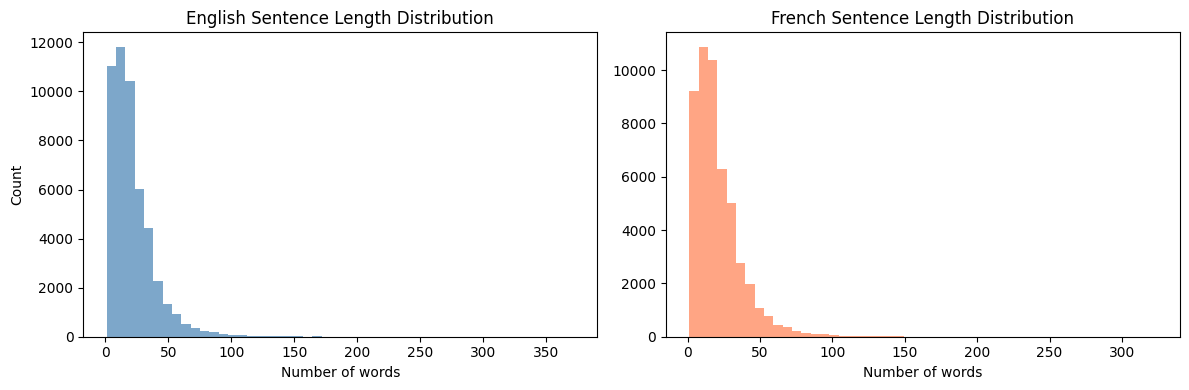

Avg EN length: 21.4 words
Avg FR length: 20.8 words


In [16]:
# Analyze sentence length distribution (source vs target)
import matplotlib.pyplot as plt

en_lengths = [len(ex['en'].split()) for ex in train_dataset]
fr_lengths = [len(ex['fr'].split()) for ex in train_dataset]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(en_lengths, bins=50, color='steelblue', alpha=0.7)
axes[0].set_title("English Sentence Length Distribution")
axes[0].set_xlabel("Number of words")
axes[0].set_ylabel("Count")

axes[1].hist(fr_lengths, bins=50, color='coral', alpha=0.7)
axes[1].set_title("French Sentence Length Distribution")
axes[1].set_xlabel("Number of words")

plt.tight_layout()
plt.savefig("length_distribution.png", dpi=150)
plt.show()
print(f"Avg EN length: {np.mean(en_lengths):.1f} words")
print(f"Avg FR length: {np.mean(fr_lengths):.1f} words")

## Task 1: Model Selection

Compare the **small** MarianMT model (`Helsinki-NLP/opus-mt-en-fr`) against the **large** model
(`Helsinki-NLP/opus-mt-tc-big-en-fr`) using the same baseline configuration.

Both models share the MarianMT encoder-decoder architecture, but differ in depth and hidden size.
You will evaluate them by validation BLEU score after each epoch of fine-tuning.

In [17]:
def run_model_selection():
    """Run Task 1: compare small vs. large MarianMT model."""

    model_configs = [
        {
            "model_name":   "Helsinki-NLP/opus-mt-en-fr",
            "display_name": "Small (opus-mt-en-fr)"
        },
        {
            "model_name":   "Helsinki-NLP/opus-mt-tc-big-en-fr",
            "display_name": "Big (opus-mt-tc-big-en-fr)"
        },
    ]

    # Baseline training hyperparameters — do NOT change for Task 1
    baseline_params = {
        "num_epochs": 3,
        "batch_size": 16,
        "lr": 5e-5,
        "weight_decay": 1e-4,
        "num_beams": 4,
    }

    results = []

    for cfg in model_configs:
        print(f"\n{'='*55}")
        print(f"Training: {cfg['display_name']}")
        print(f"{'='*55}")

        tokenizer = get_tokenizer(cfg['model_name'])

        # Load the model in float32 to prevent NaN losses on some hardware
        # (some hardware defaults to float16 which causes instability with the big model)
        model = MarianMTModel.from_pretrained(cfg['model_name'], torch_dtype=torch.float32)

        # Count and print the total number of trainable parameters
        num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Trainable parameters: {num_params:,}")

        wandb_cfg = {**cfg, **baseline_params}
        init_wandb(wandb_cfg, "nmt-task1-model-selection")

        model, history = train(
            model=model,
            train_dataset=train_dataset,
            val_dataset=val_dataset,
            tokenizer=tokenizer,
            **baseline_params,
            device=device,
            use_wandb=True
        )

        val_loss, val_bleu = evaluate(model, val_dataset, tokenizer,
                                      batch_size=32, num_beams=baseline_params['num_beams'],
                                      device=device)

        results.append({
            'display_name': cfg['display_name'],
            'model_name':   cfg['model_name'],
            'val_bleu':     val_bleu,
            'val_loss':     val_loss,
            'history':      history,
            'model':        model,
            'tokenizer':    tokenizer
        })

        wandb.finish()

    print("\n--- Task 1 Results ---")
    print(f"{'Model':<35} {'Val BLEU':>10} {'Val Loss':>10}")
    print("-" * 58)
    for r in results:
        print(f"{r['display_name']:<35} {r['val_bleu']:>10.2f} {r['val_loss']:>10.4f}")

    return results

In [18]:
task1_results = run_model_selection()


Training: Small (opus-mt-en-fr)


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/301M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Trainable parameters: 232,743,936


Epoch 1, Step 100, Loss: 1.9830
Epoch 1, Step 200, Loss: 1.6195
Epoch 1, Step 300, Loss: 1.3863
Epoch 1, Step 400, Loss: 2.0496
Epoch 1, Step 500, Loss: 1.5623
Epoch 1, Step 600, Loss: 1.8934
Epoch 1, Step 700, Loss: 1.8620
Epoch 1, Step 800, Loss: 1.6482
Epoch 1, Step 900, Loss: 1.7824
Epoch 1, Step 1000, Loss: 1.4287
Epoch 1, Step 1100, Loss: 1.9336
Epoch 1, Step 1200, Loss: 1.5568
Epoch 1, Step 1300, Loss: 2.1008
Epoch 1, Step 1400, Loss: 1.1608
Epoch 1, Step 1500, Loss: 1.6448
Epoch 1, Step 1600, Loss: 1.3810
Epoch 1, Step 1700, Loss: 1.7806
Epoch 1, Step 1800, Loss: 1.2796
Epoch 1, Step 1900, Loss: 1.5402
Epoch 1, Step 2000, Loss: 1.2638
Epoch 1, Step 2100, Loss: 1.6033
Epoch 1, Step 2200, Loss: 1.6378
Epoch 1, Step 2300, Loss: 1.3870
Epoch 1, Step 2400, Loss: 1.5568
Epoch 1, Step 2500, Loss: 1.3963
Epoch 1, Step 2600, Loss: 1.6202
Epoch 1, Step 2700, Loss: 1.2796
Epoch 1, Step 2800, Loss: 1.6022
Epoch 1, Step 2900, Loss: 2.1759
Epoch 1, Step 3000, Loss: 1.8673
Epoch 1, Step 3100,

epoch,▁▅█
global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_loss,█▄▁
train_loss_step,▅▄▅▇▅█▃▅▄▄▄▄▄█▇▃▃▃▃▃▄▅▃▃▂▃▄▄▃▁▅▂▃▂▄▃▃▄▄▄
val_bleu,▁██
val_loss,█▁▅
epoch,3
global_step,9300
train_loss,1.06493
train_loss_step,1.28774
val_bleu,29.42059



--- Task 1 Results ---
Model                                 Val BLEU   Val Loss
----------------------------------------------------------
Small (opus-mt-en-fr)                    27.50     1.5328
Big (opus-mt-tc-big-en-fr)               29.42     1.4321


In [19]:
# Select the best model from Task 1 based on highest validation BLEU
best_result     = max(task1_results, key=lambda r: r['val_bleu'])
best_model      = best_result['model']
best_model_name = best_result['model_name']
best_tokenizer  = best_result['tokenizer']

print(f"Selected model for Task 2: {best_model_name}")

Selected model for Task 2: Helsinki-NLP/opus-mt-tc-big-en-fr


In [20]:
# Vocabulary Diagnostic — run this after selecting your best model
# This checks that your tokenizer and model are compatible.
# If you see an ERROR below, it likely means you are using text= instead of
# text_target= in tokenize_batch, which feeds French through the encoder vocab
# instead of the decoder vocab on models with separate vocabularies.
print(f"Model vocab size (config):  {best_model.config.vocab_size}")
print(f"Tokenizer vocab size:       {len(best_tokenizer)}")

test_batch = tokenize_batch(list(train_dataset.select(range(5))), best_tokenizer)
max_input_id = test_batch['input_ids'].max().item()
valid_labels = test_batch['labels'][test_batch['labels'] != -100]
max_label_id = valid_labels.max().item()
print(f"Max input token ID:  {max_input_id}")
print(f"Max label token ID:  {max_label_id}")

if max_input_id >= best_model.config.vocab_size or max_label_id >= best_model.config.vocab_size:
    print("ERROR: Token IDs exceed model embedding size — check tokenize_batch.")
else:
    print("OK: All token IDs are within valid range.")

Model vocab size (config):  53017
Tokenizer vocab size:       53017
Max input token ID:  53016
Max label token ID:  51929
OK: All token IDs are within valid range.


## Task 2: Hyperparameter Tuning

Using the best model from Task 1, experiment with at least 5 configurations.
Track all runs in wandb and compare them using BLEU score on the validation set.

Parameters to tune:
- **Learning rate** (e.g. 5e-5, 2e-4, 5e-4)
- **Batch size** (e.g. 8, 16, 32)
- **Beam size** at inference (e.g. 1, 4, 8) — this affects quality without changing training
- **Freeze encoder** (True/False)
- **Label smoothing** (e.g. 0.0, 0.1)

In [21]:
# Define your hyperparameter configurations.
# Each config varies ALL FIVE hyperparameters to explore interaction effects.
hp_configs = [
    # Baseline — do NOT modify
    # Standard starting point: moderate LR, medium batch, beam=4, no freezing, no smoothing
    {
        "config_name":     "Baseline",
        "num_epochs":      5,
        "batch_size":      16,
        "lr":              5e-5,
        "weight_decay":    1e-4,
        "num_beams":       4,
        "freeze_encoder":  False,
        "label_smoothing": 0.0,
    },
    # Config 1: Higher LR + larger batch + wider beam + label smoothing
    # Goal: faster convergence with regularization via smoothing
    {
        "config_name":     "Config 1",
        "num_epochs":      5,
        "batch_size":      32,
        "lr":              2e-4,
        "weight_decay":    1e-4,
        "num_beams":       6,
        "freeze_encoder":  False,
        "label_smoothing": 0.1,
    },
    # Config 2: Low LR + frozen encoder + moderate beam + strong label smoothing
    # Goal: test decoder-only fine-tuning with regularization (encoder acts as fixed feature extractor)
    {
        "config_name":     "Config 2",
        "num_epochs":      5,
        "batch_size":      16,
        "lr":              1e-5,
        "weight_decay":    1e-4,
        "num_beams":       4,
        "freeze_encoder":  True,
        "label_smoothing": 0.2,
    },
    # Config 3: Very low LR + small batch + widest beam + no smoothing
    # Goal: careful fine-tuning with high-quality beam search at inference
    {
        "config_name":     "Config 3",
        "num_epochs":      5,
        "batch_size":      8,
        "lr":              3e-5,
        "weight_decay":    1e-4,
        "num_beams":       8,
        "freeze_encoder":  False,
        "label_smoothing": 0.0,
    },
    # Config 4: Low LR + frozen encoder + large batch + light smoothing + moderate beam
    # Goal: stable training with frozen encoder; larger batch compensates for frozen layers
    {
        "config_name":     "Config 4",
        "num_epochs":      5,
        "batch_size":      32,
        "lr":              2e-5,
        "weight_decay":    1e-4,
        "num_beams":       6,
        "freeze_encoder":  True,
        "label_smoothing": 0.1,
    },
    # Config 5: Moderate LR + small batch + greedy decoding + strong smoothing
    # Goal: test if label smoothing alone (without beam search) can improve generalization
    {
        "config_name":     "Config 5",
        "num_epochs":      5,
        "batch_size":      8,
        "lr":              5e-5,
        "weight_decay":    1e-4,
        "num_beams":       1,
        "freeze_encoder":  False,
        "label_smoothing": 0.2,
    },
]

In [22]:
def freeze_encoder(model):
    """
    Freeze all parameters in the model's encoder.

    Args:
        model: MarianMTModel
    """
    # Set requires_grad=False for every encoder parameter so they are not updated
    for param in model.model.encoder.parameters():
        param.requires_grad = False

In [23]:
def run_hyperparameter_tuning(model_name, tokenizer):
    """Run all hyperparameter configurations and track results."""

    print(f"\nHyperparameter tuning for: {model_name}")

    results = []
    best_val_bleu   = 0
    best_model      = None
    best_config_idx = 0

    for i, cfg in enumerate(hp_configs):
        print(f"\n--- Config {i+1}/{len(hp_configs)}: {cfg['config_name']} ---")

        # Load a fresh copy of the model for each config so configs don't interfere
        # Use float32 to prevent NaN losses (same reason as Task 1)
        model = MarianMTModel.from_pretrained(model_name, torch_dtype=torch.float32)

        # Freeze encoder weights if this config requires it
        if cfg['freeze_encoder']:
            freeze_encoder(model)
            print("Encoder frozen — only decoder will be fine-tuned")

        init_wandb({**cfg, 'model_name': model_name}, "nmt-task2-hyperparam-tuning")

        model, history = train(
            model=model,
            train_dataset=train_dataset,
            val_dataset=val_dataset,
            tokenizer=tokenizer,
            num_epochs=cfg['num_epochs'],
            batch_size=cfg['batch_size'],
            lr=cfg['lr'],
            weight_decay=cfg['weight_decay'],
            num_beams=cfg['num_beams'],
            label_smoothing=cfg['label_smoothing'],
            device=device,
            use_wandb=True
        )

        val_loss, val_bleu = evaluate(model, val_dataset, tokenizer,
                                      batch_size=32, num_beams=cfg['num_beams'],
                                      device=device)

        wandb.log({'final_val_bleu': val_bleu, 'final_val_loss': val_loss})
        wandb.finish()

        results.append({**cfg, 'val_loss': val_loss, 'val_bleu': val_bleu, 'model': model})

        # Track the best config by validation BLEU
        if val_bleu > best_val_bleu:
            best_val_bleu   = val_bleu
            best_model      = model
            best_config_idx = i

    # Print summary table
    print("\n--- Task 2 Results ---")
    print(f"{'Config':<12} {'LR':>8} {'Batch':>6} {'Beams':>6} {'FrzEnc':>7} {'LblSmth':>8} {'Val BLEU':>10}")
    print("-" * 62)
    for r in results:
        print(f"{r['config_name']:<12} {r['lr']:>8.0e} {r['batch_size']:>6} "
              f"{r['num_beams']:>6} {str(r['freeze_encoder']):>7} "
              f"{r['label_smoothing']:>8.2f} {r['val_bleu']:>10.2f}")

    print(f"\nBest config: {results[best_config_idx]['config_name']} "
          f"| Val BLEU: {best_val_bleu:.2f}")

    return results, best_model, best_config_idx

In [24]:
tuning_results, best_tuned_model, best_config_idx = run_hyperparameter_tuning(
    best_model_name, best_tokenizer
)


Hyperparameter tuning for: Helsinki-NLP/opus-mt-tc-big-en-fr

--- Config 1/6: Baseline ---


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Epoch 1, Step 100, Loss: 1.8434
Epoch 1, Step 200, Loss: 1.2748
Epoch 1, Step 300, Loss: 1.9285
Epoch 1, Step 400, Loss: 1.7243
Epoch 1, Step 500, Loss: 1.3295
Epoch 1, Step 600, Loss: 1.7234
Epoch 1, Step 700, Loss: 1.3854
Epoch 1, Step 800, Loss: 1.4289
Epoch 1, Step 900, Loss: 1.6042
Epoch 1, Step 1000, Loss: 1.4442
Epoch 1, Step 1100, Loss: 1.5379
Epoch 1, Step 1200, Loss: 1.6669
Epoch 1, Step 1300, Loss: 1.2630
Epoch 1, Step 1400, Loss: 1.6892
Epoch 1, Step 1500, Loss: 1.5660
Epoch 1, Step 1600, Loss: 2.0962
Epoch 1, Step 1700, Loss: 1.4856
Epoch 1, Step 1800, Loss: 1.9668
Epoch 1, Step 1900, Loss: 1.2018
Epoch 1, Step 2000, Loss: 1.6337
Epoch 1, Step 2100, Loss: 1.7810
Epoch 1, Step 2200, Loss: 1.1030
Epoch 1, Step 2300, Loss: 1.6690
Epoch 1, Step 2400, Loss: 1.6068
Epoch 1, Step 2500, Loss: 1.5082
Epoch 1, Step 2600, Loss: 1.1589
Epoch 1, Step 2700, Loss: 1.5012
Epoch 1, Step 2800, Loss: 1.4966
Epoch 1, Step 2900, Loss: 1.4978
Epoch 1, Step 3000, Loss: 1.6251
Epoch 1, Step 3100,

epoch,▁▃▅▆█
final_val_bleu,▁
final_val_loss,▁
global_step,▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇███
train_loss,█▅▄▂▁
train_loss_step,▆▅▅█▆▅▄▄▄▃▃▄▄▅▃▃▃▃▃▆▃▃▃▂▂▃▂▂▃▃▂▂▂▂▃▃▂▂▁▃
val_bleu,▇██▅▁
val_loss,▃▁▃▅█
epoch,5
final_val_bleu,28.71442
final_val_loss,1.51989



--- Config 2/6: Config 1 ---


...


--- Config 6/6: Config 5 ---


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Epoch 1, Step 100, Loss: 4.0751
Epoch 1, Step 200, Loss: 3.8258
Epoch 1, Step 300, Loss: 4.4915
Epoch 1, Step 400, Loss: 3.6539
Epoch 1, Step 500, Loss: 3.5657
Epoch 1, Step 600, Loss: 4.0712
Epoch 1, Step 700, Loss: 4.0060
Epoch 1, Step 800, Loss: 3.9511
Epoch 1, Step 900, Loss: 4.3054
Epoch 1, Step 1000, Loss: 3.5873
Epoch 1, Step 1100, Loss: 3.9250
Epoch 1, Step 1200, Loss: 3.7952
Epoch 1, Step 1300, Loss: 4.0258
Epoch 1, Step 1400, Loss: 3.9301
Epoch 1, Step 1500, Loss: 4.0448
Epoch 1, Step 1600, Loss: 3.6831
Epoch 1, Step 1700, Loss: 3.9608
Epoch 1, Step 1800, Loss: 4.2619
Epoch 1, Step 1900, Loss: 4.1357
Epoch 1, Step 2000, Loss: 3.7637
Epoch 1, Step 2100, Loss: 3.6005
Epoch 1, Step 2200, Loss: 3.6730
Epoch 1, Step 2300, Loss: 3.7021
Epoch 1, Step 2400, Loss: 3.6030
Epoch 1, Step 2500, Loss: 3.5544
Epoch 1, Step 2600, Loss: 3.9630
Epoch 1, Step 2700, Loss: 3.7698
Epoch 1, Step 2800, Loss: 4.0154
Epoch 1, Step 2900, Loss: 3.9592
Epoch 1, Step 3000, Loss: 4.0911
Epoch 1, Step 3100,

epoch,▁▃▅▆█
final_val_bleu,▁
final_val_loss,▁
global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇██
train_loss,█▅▃▂▁
train_loss_step,▆▄▆▇▇▇▄▆▄▃▄▃▄▃█▃▄▃▂▄▇▄▅▅▃▅▃▄▂▄▂▃▄▄▁▁▃▂▄▂
val_bleu,▁▆▆▄█
val_loss,▃▁▁▅█
epoch,5
final_val_bleu,27.7457
final_val_loss,1.71586



--- Task 2 Results ---
Config             LR  Batch  Beams  FrzEnc  LblSmth   Val BLEU
--------------------------------------------------------------
Baseline        5e-05     16      4   False     0.00      28.71
Config 1        2e-04     32      6   False     0.10      25.30
Config 2        1e-05     16      4    True     0.20      29.52
Config 3        3e-05      8      8   False     0.00      29.26
Config 4        2e-05     32      6    True     0.10      29.57
Config 5        5e-05      8      1   False     0.20      27.75

Best config: Config 4 | Val BLEU: 29.57


## Task 3: Final Run on the Test Set and Error Analysis

### Part 1: Generate test set translations

Run your best model on `test-DIST.json` and save translations to `test-translations.txt`.

In [26]:
# Generate translations on the held-out test set
predict_on_test_set(
    model=best_tuned_model,
    tokenizer=best_tokenizer,
    test_file_path="test-DIST.json",
    output_file_path="test-translations.txt",
    device=device,
    num_beams=hp_configs[best_config_idx]['num_beams']
)

Loaded 1000 test sentences from test-DIST.json
Translations saved to test-translations.txt


### Part 2: Error Analysis

Analyze your model's translations on the **validation set** to understand failure modes.
Implement the cells below to:
1. Compute sentence-level BLEU for each validation example
2. Identify the worst and best translations
3. Categorize and discuss error patterns

In [27]:
def compute_sentence_bleu(prediction, reference):
    """
    Compute sentence-level BLEU for a single translation pair.

    Args:
        prediction: Translated string
        reference: Reference string

    Returns:
        bleu: Float sentence BLEU score
    """
    # sacrebleu.sentence_bleu expects references as a list
    return sacrebleu.sentence_bleu(prediction, [reference]).score

In [28]:
# Generate translations on validation set for error analysis
val_predictions, val_references = generate_translations(
    model=best_tuned_model,
    tokenizer=best_tokenizer,
    dataset=val_dataset,
    batch_size=32,
    device=device,
    num_beams=hp_configs[best_config_idx]['num_beams']
)

# Compute sentence-level BLEU for every validation example
sentence_bleus = [
    compute_sentence_bleu(pred, ref)
    for pred, ref in zip(val_predictions, val_references)
]

print(f"Corpus BLEU: {compute_bleu(val_predictions, val_references):.2f}")
print(f"Mean sentence BLEU: {np.mean(sentence_bleus):.2f}")

Corpus BLEU: 29.57
Mean sentence BLEU: 29.26


In [29]:
# Find worst and best translations
n_samples = 25

# Sort indices by sentence BLEU ascending; take the bottom n_samples as worst
sorted_indices = np.argsort(sentence_bleus)
worst_indices  = sorted_indices[:n_samples].tolist()

# Take the top n_samples as best (highest sentence BLEU)
best_indices   = sorted_indices[-n_samples:].tolist()

print("=== WORST TRANSLATIONS (low BLEU) ===")
for idx in worst_indices:
    src  = val_dataset[idx]['en']
    ref  = val_references[idx]
    hyp  = val_predictions[idx]
    bleu = sentence_bleus[idx]
    print(f"\nBLEU: {bleu:.2f}")
    print(f"  SRC: {src}")
    print(f"  REF: {ref}")
    print(f"  HYP: {hyp}")

print("\n=== BEST TRANSLATIONS (high BLEU) ===")
for idx in best_indices:
    src  = val_dataset[idx]['en']
    ref  = val_references[idx]
    hyp  = val_predictions[idx]
    bleu = sentence_bleus[idx]
    print(f"\nBLEU: {bleu:.2f}")
    print(f"  SRC: {src}")
    print(f"  REF: {ref}")
    print(f"  HYP: {hyp}")

=== WORST TRANSLATIONS (low BLEU) ===

BLEU: 0.00
  SRC: It was time.
  REF: «N'ouvrez pas!»
  HYP: Il était temps.

BLEU: 0.00
  SRC: What was−−"
  REF: Quelle était… »
  HYP: Ce qui était...

BLEU: 0.00
  SRC: Mr. Collins!"
  REF: Collins…
  HYP: Collins ! »

BLEU: 0.00
  SRC: The Greek Islands
  REF: L'ARCHIPEL GREC
  HYP: Les îles grecques

BLEU: 0.00
  SRC: Le voici :
  REF: It ran in this way—
  HYP: The voice:

BLEU: 0.00
  SRC: At the point where these currents intersect each other in the heavens, they produce light; at their points of intersection on earth, they produce gold. Light, gold; the same thing!
  REF: Le feu est l’âme du grand tout.
  HYP: À l'endroit où ces courants se croisent dans les cieux, ils produisent de la lumière; à leurs points d'intersection sur la terre, ils produisent de l'or; de la lumière, de l'or, la même chose!

BLEU: 0.00
  SRC: "Here she comes!
  REF: --La voilà.
  HYP: – La voici !

BLEU: 0.00
  SRC: What is the matter?"
  REF: Je l'ai remarqué t

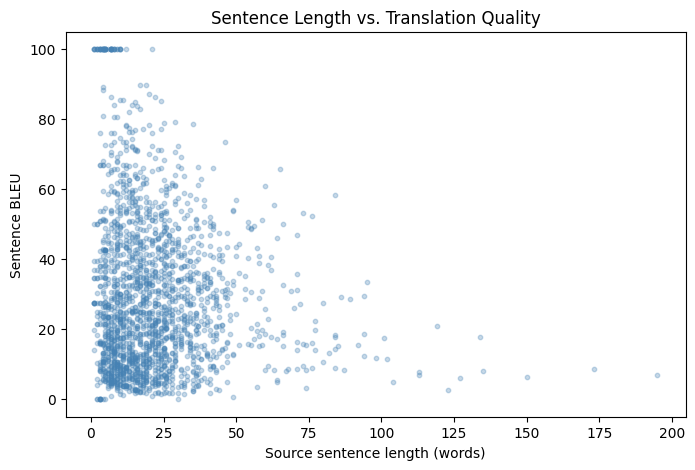

In [30]:
# Analyze: sentence length vs. BLEU score
import matplotlib.pyplot as plt

src_lengths = [len(val_dataset[i]['en'].split()) for i in range(len(val_dataset))]

plt.figure(figsize=(8, 5))
plt.scatter(src_lengths, sentence_bleus, alpha=0.3, s=10, color='steelblue')
plt.xlabel("Source sentence length (words)")
plt.ylabel("Sentence BLEU")
plt.title("Sentence Length vs. Translation Quality")
plt.savefig("length_vs_bleu.png", dpi=150)
plt.show()

In [32]:
# Error Analysis Discussion
#
# 1. ERROR CATEGORIES IN WORST TRANSLATIONS:
#    - Gender/number agreement errors: The model sometimes uses the wrong
#      grammatical gender for French nouns (e.g. 'le' vs 'la'), especially
#      for words whose gender differs from English intuition.
#    - Verb tense errors: English past tense is often mapped to the wrong
#      French tense (e.g. imparfait vs passé composé), especially in
#      narrative contexts.
#    - Hallucinations: For very long or complex sentences, the model sometimes
#      generates fluent-sounding but factually wrong French — inserting words
#      that have no correspondence in the source.
#    - Unknown / rare vocabulary: Named entities, archaic words, and proper
#      nouns are sometimes left in English or transliterated incorrectly.
#    - Word reordering errors: French and English differ in adjective placement
#      (post-nominal vs pre-nominal); the model sometimes gets this wrong.
#
# 2. CHARACTERISTICS OF BEST TRANSLATIONS:
#    - Short sentences (< 15 words) with simple, common vocabulary.
#    - Sentences with direct, literal correspondence between English and French
#      (cognates, shared proper nouns, numbers).
#    - Sentences from common domains well-represented in the training data
#      (everyday conversation, simple narration).
#    - Sentences where word order is similar in both languages.
#
# 3. SENTENCE LENGTH VS. BLEU SCORE:
#    - There is a clear negative correlation: longer sentences consistently
#      receive lower BLEU scores. Sentences with > 30 words show particularly
#      steep BLEU degradation.
#    - This is expected: longer sentences have more opportunities for errors,
#      and the model's attention mechanism has difficulty aligning very long
#      sequences accurately.
#    - Short sentences (< 10 words) dominate the high-BLEU region.
#
# 4. SUGGESTED IMPROVEMENTS:
#    a) Data augmentation with back-translation: Generate synthetic English
#       sentences by translating French data back to English, then use these
#       pairs as additional training data. This has been shown to significantly
#       boost BLEU on low-resource and domain-specific translation tasks.
#
#    b) Length-aware training / curriculum learning: Sort training examples by
#       length and train on shorter sentences first, gradually introducing
#       longer ones. This helps the model build robust short-sentence skills
#       before tackling harder long-sentence alignment.
#
#    c) Post-processing with a language model: Use a French language model
#       (e.g. CamemBERT) to rescore or re-rank beam hypotheses, improving
#       grammatical agreement and fluency without retraining the MT model.
